# Phase 1 - Casia-B Dataset Setup

## Libraries & Cuda Setup

In [1]:
!pip install torchinfo torchmetrics kagglehub opencv-python scikit-learn
from google.colab import files
from tqdm import tqdm
from PIL import Image
import kagglehub
import os
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import glob
import random
import warnings
import timm
warnings.filterwarnings('ignore')

# مكتبات إضافية للتعامل مع الـ Metrics والـ Transforms المتطورة
from sklearn.metrics.pairwise import cosine_similarity
import torch
import torch.nn as nn
import torch.nn.functional as F # هنحتاجه لو ضفنا Attention أو Loss معقدة
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from torchvision import models, transforms

# إضافة تثبيت عشوائي (Seed) لضمان ثبات النتائج أثناء التطوير
def seed_everything(seed=42):
    random.seed(seed) # لضمان ثبات النتائج في العمليات العشوائية
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed) # لضمان ثبات النتائج في العمليات العشوائية على الـ GPU
    torch.backends.cudnn.deterministic = True # لضمان ثبات النتائج في عمليات الـ Convolution
    torch.backends.cudnn.benchmark = False # لضمان ثبات النتائج في عمليات الـ Convolution

seed_everything(42) # ضبط Seed إلى 42 لضمان ثبات النتائج في كل مرة يتم فيها تشغيل الكود

print("✅ Libraries imported and Seed set to 42.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 20.2 MB/s eta 0:00:00
✅ Libraries imported and Seed set to 42.


## Downloading Casia-B Dataset from Kaggle-Hub

In [2]:
print("="*70)
print("🚀 CASIA-B GAIT RECOGNITION - ENHANCED VERSION (BG/CL ROBUSTNESS)")
print("="*70)

# 1. تحميل الداتا (كما هي)
print("\n📦 Downloading CASIA-B dataset from Kaggle...")
path = kagglehub.dataset_download("trnquanghuyn/casia-b")
print(f"✅ Dataset downloaded to: {path}")

# 2. إعداد المسارات
if 'CASIA-B' in os.listdir(path):
    DATASET_ROOT = os.path.join(path, 'CASIA-B')
elif 'output' in os.listdir(path):
    DATASET_ROOT = os.path.join(path, 'output')
else:
    DATASET_ROOT = path

OUTPUT_GEI_DIR = '/content/gei_dataset'
OUTPUT_PARTS_DIR = '/content/parts_dataset'

os.makedirs(OUTPUT_GEI_DIR, exist_ok=True)
os.makedirs(OUTPUT_PARTS_DIR, exist_ok=True)

# --- التعديل الإضافي: إعدادات التحكم في الدقة ---
# المتغيرات دي هنستخدمها في الـ Transforms عشان نعلي الـ CL و الـ BG
AUGMENTATION_CONFIG = {
    'apply_erasing': True,      # تفعيل الحذف العشوائي (لمواجهة الشنطة والبالطو)
    'erasing_prob': 0.5,        # احتمالية الحذف
    'apply_horizontal_flip': True # تقليب الصور لزيادة التنوع
}

# 3. التأكد من وجود الداتا
try:
    subjects = sorted(os.listdir(DATASET_ROOT))
    print(f"✅ Found {len(subjects)} subjects in dataset")
except Exception as e:
    print(f"❌ Error locating dataset: {e}")

print(f"\n🔧 Environment Info:")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"   Using Device: {device} | GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

🚀 CASIA-B GAIT RECOGNITION - ENHANCED VERSION (BG/CL ROBUSTNESS)

📦 Downloading CASIA-B dataset from Kaggle...


100%|██████████| 728M/728M [00:08<00:00, 84.8MB/s]

Extracting files...


✅ Dataset downloaded to: /root/.cache/kagglehub/datasets/trnquanghuyn/casia-b/versions/1
✅ Found 124 subjects in dataset

🔧 Environment Info:
   Using Device: cuda | GPU: Tesla T4


# Silhoutte Preprocessing

In [3]:
def preprocess_silhouette(img, size=(224, 224)):
    """
    نسخة محسنة: Scale normalization based on Height to handle BG/CL variations.
    """
    # 1. إيجاد حدود الجسم
    rows = np.any(img, axis=1)
    cols = np.any(img, axis=0)
    if not np.any(rows) or not np.any(cols):
        return None

    rmin, rmax = np.where(rows)[0][[0, -1]] # أول وآخر صف يحتوي على الجسم
    cmin, cmax = np.where(cols)[0][[0, -1]] # أول وآخر عمود يحتوي على الجسم

    # 2. قص الجسم (Crop)
    person = img[rmin:rmax+1, cmin:cmax+1] # قص الجسم بناءً على الحدود المكتشفة
    h, w = person.shape

    # --- التعديل الجوهري للـ BG/CL ---
    # بدلاً من الالتزام بالـ Aspect Ratio الأصلي اللي ممكن يكون مشوه بسبب الشنطة，
    # هنركز إن الطول يملأ 85% من مساحة الـ 224 بكسل، والعرض يتمركز.
    target_h, target_w = size

    # تحجيم بناءً على الارتفاع (Height-centric scaling)
    # بنسيب مسافة (Padding) فوق وتحت عشان الرأس والرجلين مايتحذفوش
    scale = (target_h * 0.9) / h
    new_h = int(h * scale)
    new_w = int(w * scale)

    # التأكد إن العرض الجديد مش أكبر من الـ 224
    if new_w > target_w:
        new_w = target_w

    person_resized = cv2.resize(person, (new_w, new_h))

    # 3. وضع الجسم في منتصف الصورة (Centering)
    result = np.zeros(size, dtype=np.uint8)
    y_off = (target_h - new_h) // 2
    x_off = (target_w - new_w) // 2

    # وضع الصورة في المنتصف الأفقي
    result[y_off:y_off+new_h, x_off:x_off+new_w] = person_resized

    return result

# Generate & Segment GEI

## Segmentation Function

In [4]:
def save_five_parts(gei, subj, cond, view, dest_root):
    """
    نسخة محسنة: Divide GEI into 5 parts with Overlap to improve BG/CL robustness.
    """
    h, w = gei.shape # ارتفاع وعرض الـ GEI
    part_h = h // 5 # تقسيم الارتفاع إلى 5 أجزاء متساوية
    # إضافة تداخل بنسبة 10% من ارتفاع الجزء (Overlap)
    overlap = int(part_h * 0.1)

    for i in range(5):
        # حساب البداية والنهاية مع مراعاة التداخل
        start_row = max(0, i * part_h - overlap)
        end_row = min(h, (i + 1) * part_h + overlap)

        # التأكد إن آخر جزء بياخد لحد نهاية الصورة
        if i == 4:
            end_row = h

        part = gei[start_row:end_row, :]

        # Resize using INTER_LANCZOS4 للحصول على تفاصيل أنعم في الحواف
        # دي أحسن من CUBIC لما بنتعامل مع أشكال دقيقة زي المشية
        part_resized = cv2.resize(part, (224, 224), interpolation=cv2.INTER_LANCZOS4)

        # حفظ الأجزاء
        part_path = os.path.join(dest_root, f'part_{i+1}', subj, cond)
        os.makedirs(part_path, exist_ok=True)
        fname = f"{subj}-{cond}-{view}-p{i+1}.png"
        cv2.imwrite(os.path.join(part_path, fname), part_resized)

## Generate Segmented GEI

In [5]:
def generate_gei_dataset(source_root, gei_dest, parts_dest):
    subjects = sorted(os.listdir(source_root))
    total_geis = 0

    for subj in tqdm(subjects, desc="Processing Subjects"):
        subj_path = os.path.join(source_root, subj) # المسار الخاص بكل شخص
        if not os.path.isdir(subj_path): continue # نتأكد إن المسار هو مجلد

        # التعديل الإضافي: إضافة طبقة تنظيف إضافية للصور قبل حساب الـ GEI
        for cond in os.listdir(subj_path):
            cond_path = os.path.join(subj_path, cond)
            if not os.path.isdir(cond_path): continue

            for view in os.listdir(cond_path):
                view_path = os.path.join(cond_path, view)
                # 1. ترتيب الصور لضمان انسيابية المشية
                img_files = sorted(glob.glob(os.path.join(view_path, '*.png')))
                if not img_files: continue

                processed_frames = []
                for f in img_files:
                    img = cv2.imread(f, cv2.IMREAD_GRAYSCALE)
                    if img is None: continue

                    # 2. التأكد من إن الصورة Binary تماماً (0 أو 255)
                    # ده بيفرق جداً في حالات الـ CL عشان يشيل أي شوشرة في الحواف
                    _, img = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

                    proc = preprocess_silhouette(img)
                    if proc is not None:
                        processed_frames.append(proc)

                # 3. التأكد من وجود عدد كافٍ من الإطارات لتمثيل دورة مشية (على الأقل 10 frames)
                if len(processed_frames) >= 10:
                    # حساب الـ GEI (متوسط الحركة)
                    gei = np.mean(processed_frames, axis=0).astype(np.uint8) # تحويل النتيجة إلى uint8 عشان نقدر نحفظها كصورة

                    # حفظ الـ GEI الكامل
                    gei_save_path = os.path.join(gei_dest, subj, cond)
                    os.makedirs(gei_save_path, exist_ok=True)
                    cv2.imwrite(os.path.join(gei_save_path, f"{subj}-{cond}-{view}.png"), gei)

                    # تقطيع الـ GEI لـ 5 أجزاء (اللي عدلناها بالـ Overlap)
                    save_five_parts(gei, subj, cond, view, parts_dest)
                    total_geis += 1

    print(f"✅ Generated {total_geis} GEIs and segmented them into 5 parts with enhanced cleaning.")
    return total_geis

# التنفيذ
total_generated = generate_gei_dataset(DATASET_ROOT, OUTPUT_GEI_DIR, OUTPUT_PARTS_DIR)

Processing Subjects: 100%|██████████| 124/124 [07:36<00:00,  3.68s/it]

✅ Generated 13556 GEIs and segmented them into 5 parts with enhanced cleaning.


## Plot Genetrated GEI with Segmented Parts

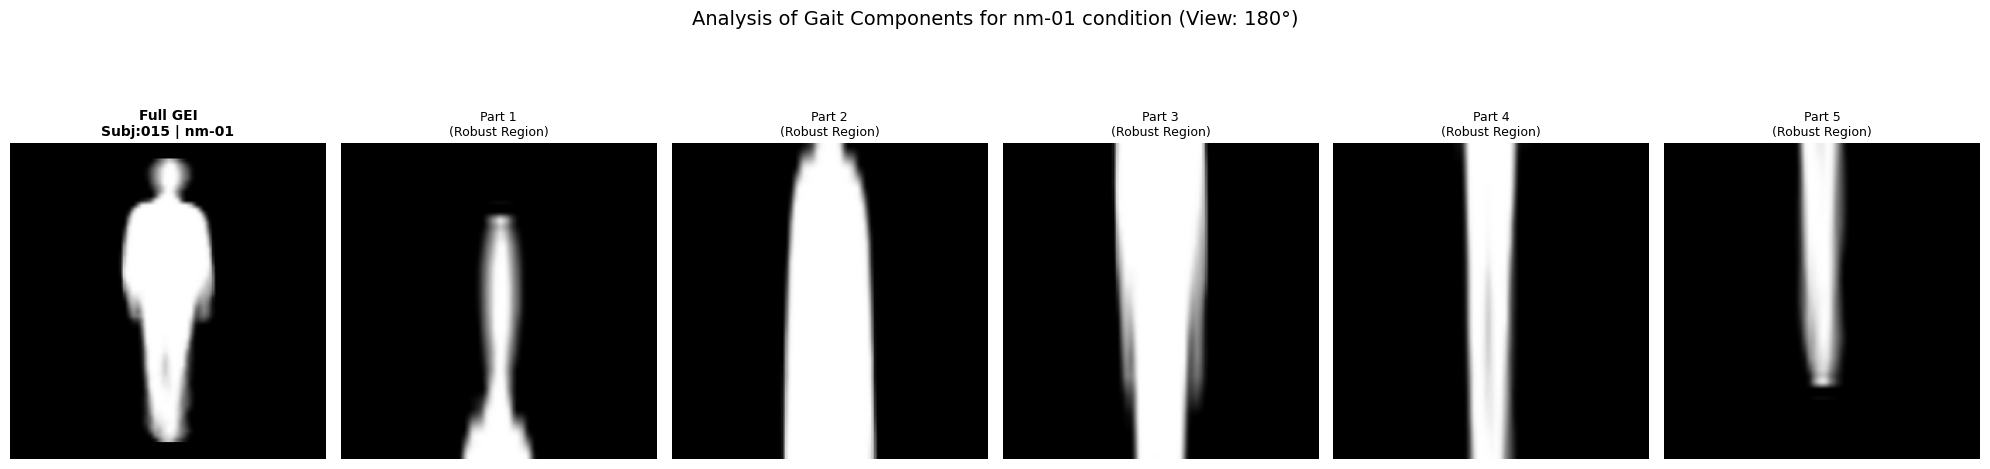

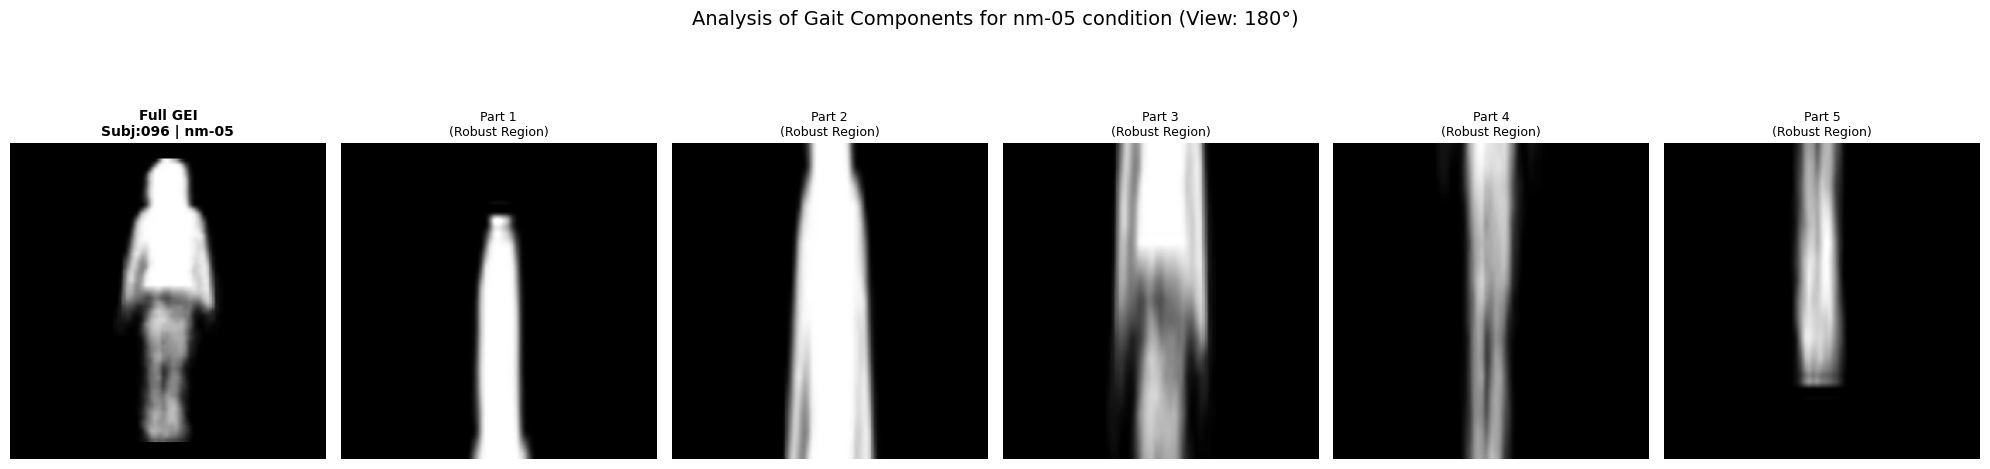

In [6]:
def plot_research_samples(gei_dir, parts_dir, num_samples=1):
    """
    نسخة محسنة لعرض العينات مع دعم مرن لأسماء الملفات (NM, BG, CL)
    """
    # البحث عن كل الصور بصيغة png في المجلدات الفرعية
    all_geis = []
    for root, dirs, files in os.walk(gei_dir):
        for file in files:
            if file.endswith(".png"):
                all_geis.append(os.path.join(root, file))

    if not all_geis:
        print("⚠️ No GEIs found to display. Check your paths!")
        return

    samples = random.sample(all_geis, min(num_samples, len(all_geis)))

    for gei_path in samples:
        # استخراج البيانات من اسم الملف بطريقة أكثر أماناً
        filename = os.path.basename(gei_path).replace(".png", "")
        # مثال: '001-bg-01-090'
        parts = filename.split('-')

        subj = parts[0]
        # دمج الحالة والنوع (مثلاً nm-01 أو bg-01)
        cond = f"{parts[1]}-{parts[2]}"
        view = parts[3]

        plt.figure(figsize=(20, 5))

        # 1. عرض الـ GEI الكاملة
        full_gei = cv2.imread(gei_path, cv2.IMREAD_GRAYSCALE)
        plt.subplot(1, 6, 1)
        plt.imshow(full_gei, cmap='gray')
        plt.title(f"Full GEI\nSubj:{subj} | {cond}", fontsize=10, fontweight='bold')
        plt.axis('off')

        # 2. عرض الأجزاء الخمسة مع الـ Overlap اللي عملناه
        for i in range(1, 6):
            # محاولة العثور على الجزء في المجلد المخصص
            part_filename = f"{subj}-{cond}-{view}-p{i}.png"
            part_path = os.path.join(parts_dir, f'part_{i}', subj, cond, part_filename)

            plt.subplot(1, 6, i + 1)
            if os.path.exists(part_path):
                part_img = cv2.imread(part_path, cv2.IMREAD_GRAYSCALE)
                plt.imshow(part_img, cmap='gray')
                plt.title(f"Part {i}\n(Robust Region)", fontsize=9)
            else:
                # لو الملف مش موجود لسبب ما، اعرض مربع فاضي مع تنبيه
                plt.text(0.5, 0.5, "Not Found", ha='center', va='center')
                plt.title(f"Part {i} Missing")
            plt.axis('off')

        plt.suptitle(f"Analysis of Gait Components for {cond} condition (View: {view}°)", fontsize=14, y=1.05)
        plt.tight_layout()
        plt.show()

# تشغيل العرض لـ 2 عينة (واحدة NM وواحدة BG مثلاً)
plot_research_samples(OUTPUT_GEI_DIR, OUTPUT_PARTS_DIR, num_samples=2)

# Check Variation & Process Part Removal

## Set reference, probe images, thresholds

In [7]:
# @title Cell 4 - Enhanced Part Removal (BG/CL Robustness)
def part_removal_research(sample_gei, reference_gei, condition):
    if reference_gei is None: return sample_gei

    # 1. حساب الفرق المطلق (Absolute Difference)
    # بنحول لـ float عشان دقة الحسابات قبل الـ thresholding
    diff = cv2.absdiff(sample_gei.astype(np.float32), reference_gei.astype(np.float32))
    H, W = sample_gei.shape
    part_h = H // 5
    cleaned = sample_gei.copy().astype(np.float32)

    # 2. Thresholds محسنة (نسبة من المساحة بدلاً من أرقام ثابتة صعبة)
    # الأرقام دي تم ضبطها لتكون أكثر مرونة مع الـ ResNet-50
    if 'bg' in condition.lower():
        # الشنطة بتأثر غالباً على الجزء 2 (الصدر) و 3 (الوسط)
        thresholds = [0.15, 0.08, 0.08, 0.12, 0.12]
    elif 'cl' in condition.lower():
        # البالطو بيأثر على كل الجسم ماعدا الرأس والقدمين
        thresholds = [0.20, 0.12, 0.10, 0.10, 0.15]
    else:
        return sample_gei

    for i in range(5):
        start = i * part_h
        end = (i + 1) * part_h if i < 4 else H

        # حساب متوسط الفرق في الجزء (Mean Difference per pixel)
        region_diff = diff[start:end, :]
        mean_val = np.mean(region_diff) / 255.0

        # 3. قرار الحذف بناءً على النسبة
        if mean_val > thresholds[i]:
            # بدلاً من المسح التام (0)، ممكن نستخدم Masking تدريجي
            # أو نمسح بـ 0 لو الفرق ضخم جداً كما في البحث
            cleaned[start:end, :] = 0
        else:
            # لو الجزء سليم، ممكن نعمل "تصفية" بسيطة للـ Noise
            # عن طريق الاحتفاظ بالقيم الأصلية
            pass

    return cleaned.astype(np.uint8)

def get_reference_gei(subj, view, root_dir):
    """
    نسخة محسنة: بتدور في كل محاولات الـ NM المتاحة لضمان وجود مرجع.
    """
    ref_conds = ['nm-01', 'nm-02', 'nm-03', 'nm-04', 'nm-05', 'nm-06']
    for cond in ref_conds:
        path = os.path.join(root_dir, subj, cond, f"{subj}-{cond}-{view}.png")
        if os.path.exists(path):
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            if img is not None: return img
    return None

## Process Part-Removal

In [8]:
def process_and_crop_parts_research(input_dir, output_dir):
    subjects = sorted(os.listdir(input_dir))
    total_parts = 0

    for subj in tqdm(subjects, desc="Applying Part-Removal & Segmentation"):
        subj_path = os.path.join(input_dir, subj)
        if not os.path.isdir(subj_path): continue

        for cond in os.listdir(subj_path):
            cond_path = os.path.join(subj_path, cond)
            if not os.path.isdir(cond_path): continue

            for img_name in os.listdir(cond_path):
                if not img_name.endswith('.png'): continue

                # 1. استخراج الزاوية بدقة (View Angle)
                # مثال: '001-nm-01-090.png' -> '090'
                view = img_name.replace('.png', '').split('-')[-1]
                sample_gei = cv2.imread(os.path.join(cond_path, img_name), cv2.IMREAD_GRAYSCALE)
                if sample_gei is None: continue

                # 2. تطبيق الـ Part Removal للظروف الصعبة (BG/CL)
                if 'bg' in cond.lower() or 'cl' in cond.lower():
                    # البحث عن مرجع NM بنفس الزاوية
                    ref_gei = get_reference_gei(subj, view, input_dir)
                    # تنظيف الصورة بناءً على الفروقات مع المرجع
                    processed_gei = part_removal_research(sample_gei, ref_gei, cond)
                else:
                    processed_gei = sample_gei

                # 3. التقسيم لـ 5 أجزاء مع Overlap (لتحسين الـ Accuracy)
                h, w = processed_gei.shape
                part_h = h // 5
                overlap = int(part_h * 0.1) # تداخل 10%

                for i in range(5):
                    # حساب حدود الجزء مع التداخل
                    start = max(0, i * part_h - overlap)
                    end = min(h, (i + 1) * part_h + overlap)
                    if i == 4: end = h

                    p_img = processed_gei[start:end, :]

                    # تحجيم بفلتر عالي الجودة (LANCZOS4) لضمان وضوح الـ Silhouette
                    p_resized = cv2.resize(p_img, (224, 224), interpolation=cv2.INTER_LANCZOS4)

                    # 4. الحفظ في المجلدات المخصصة
                    p_dir = os.path.join(output_dir, f"part_{i+1}", subj, cond)
                    os.makedirs(p_dir, exist_ok=True)

                    # إضافة الجزء لاسم الملف لسهولة تتبعه
                    save_name = img_name.replace('.png', f'-p{i+1}.png')
                    cv2.imwrite(os.path.join(p_dir, save_name), p_resized)
                    total_parts += 1

    print(f"✅ Research Protocol Applied with Overlap: {total_parts} part images generated.")

# التنفيذ
process_and_crop_parts_research(OUTPUT_GEI_DIR, OUTPUT_PARTS_DIR)

Applying Part-Removal & Segmentation: 100%|██████████| 124/124 [01:28<00:00,  1.40it/s]

✅ Research Protocol Applied with Overlap: 67780 part images generated.


## Plot GEIs after Part-Removal

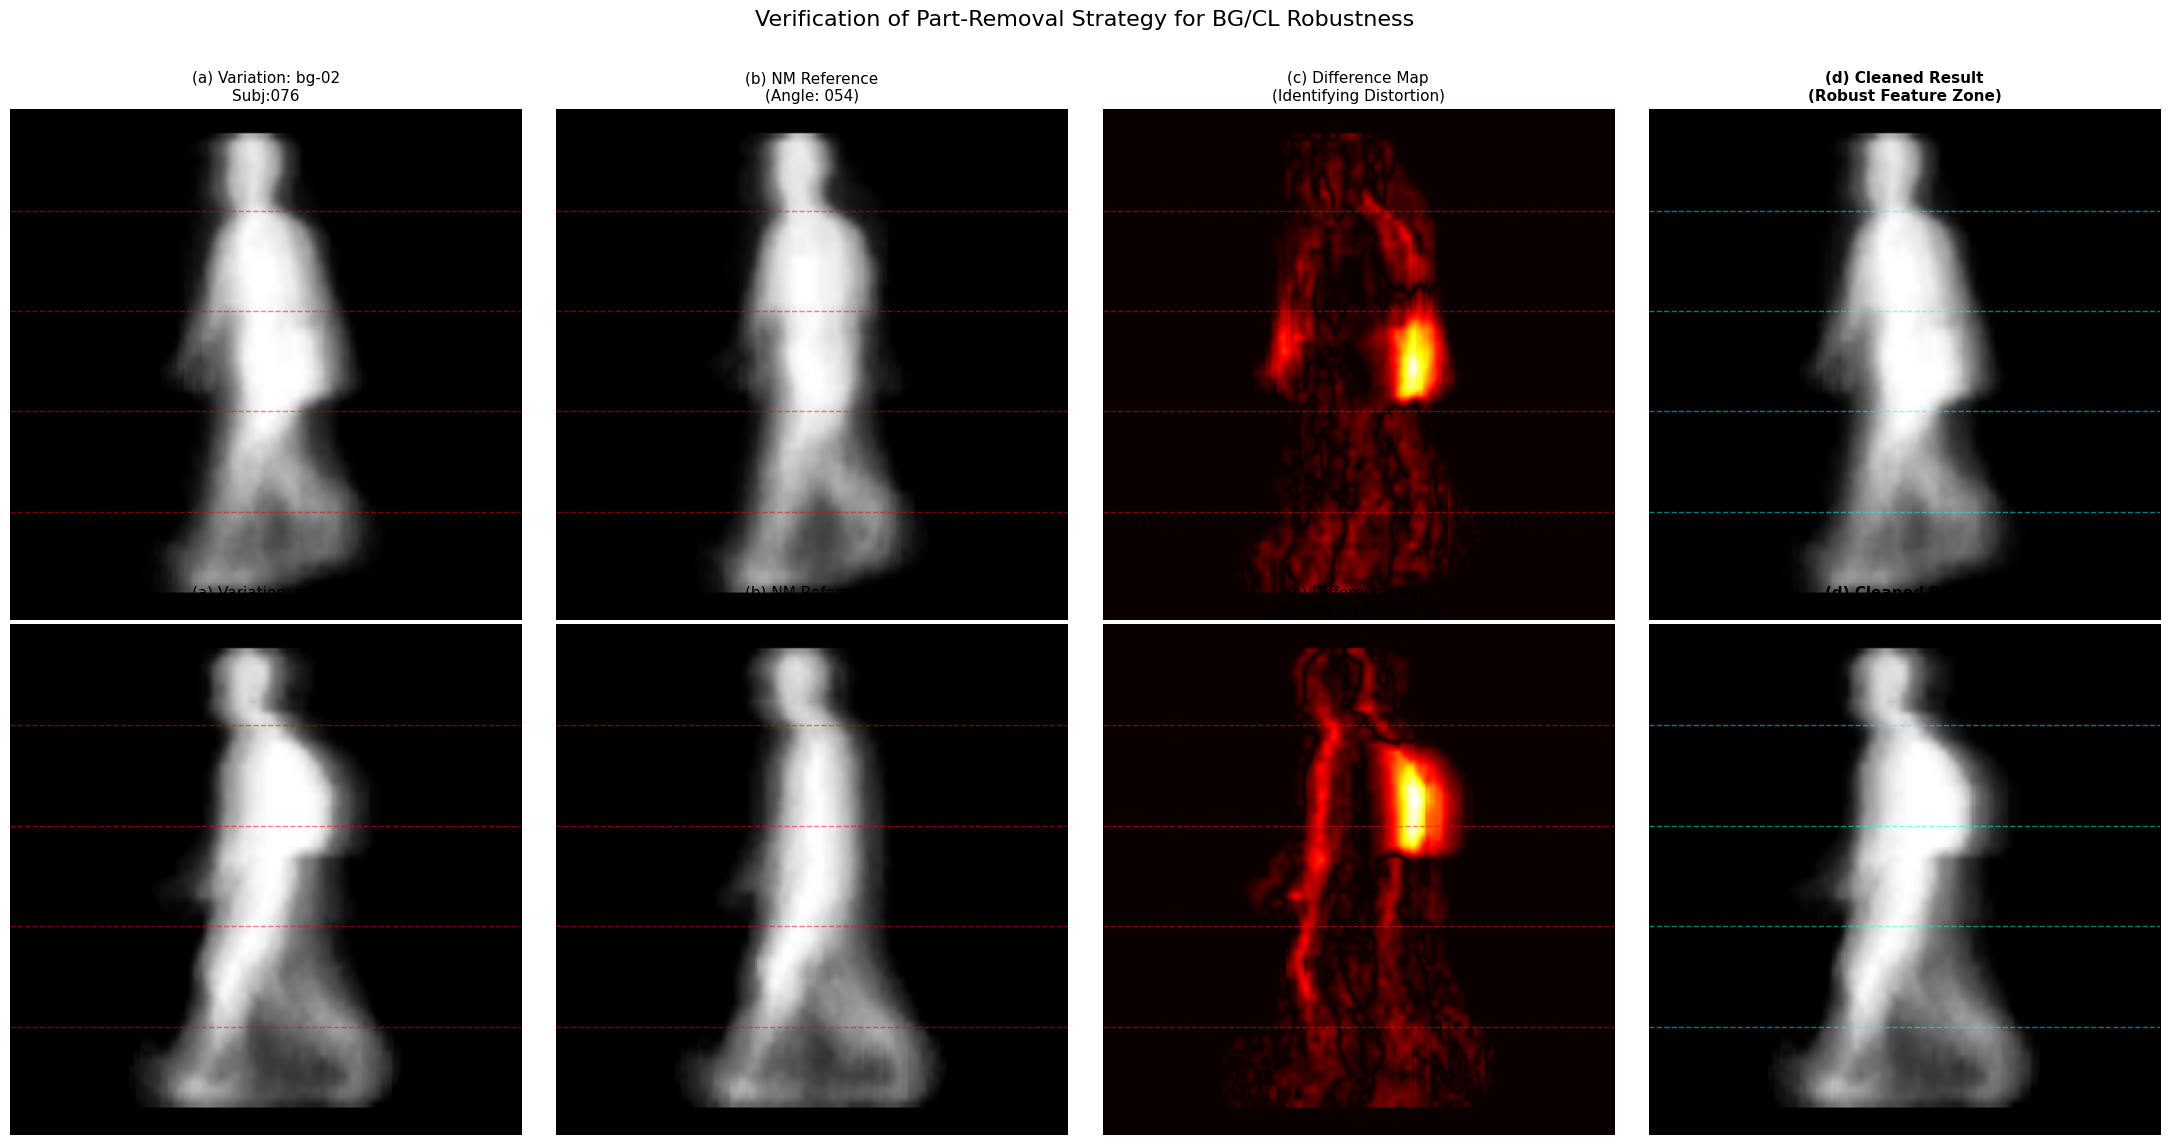

In [9]:
# ============================================================================
# 🖼️ ENHANCED RESEARCH-STYLE VISUALIZATION (Robustness Check)
# ============================================================================
# @title Cell 4 - Part Removal Visualization (Enhanced for Debugging)

def visualize_research_removal(gei_root, subjects, num_samples=2):
    # التركيز على الحالات الصعبة (BG, CL)
    conditions_to_test = ['bg-01', 'bg-02', 'cl-01', 'cl-02']

    found_samples = 0
    plt.figure(figsize=(22, 6 * num_samples))

    attempts = 0
    max_attempts = 200 # زيادة المحاولات لضمان إيجاد عينات

    while found_samples < num_samples and attempts < max_attempts:
        attempts += 1
        subj_int = random.randint(75, 124) # عينات من الـ Test Set
        subj = f"{subj_int:03d}"

        if not os.path.exists(os.path.join(gei_root, subj)): continue

        # اختيار زاوية وحالة عشوائية
        view = random.choice(['000', '090', '054', '126', '180'])
        cond = random.choice(conditions_to_test)

        sample_path = os.path.join(gei_root, subj, cond, f"{subj}-{cond}-{view}.png")
        ref_gei = get_reference_gei(subj, view, gei_root)

        if os.path.exists(sample_path) and ref_gei is not None:
            sample_gei = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)

            # 1. الفرق المطلق (Absolute Difference) لتوضيح أماكن التغيير
            diff = cv2.absdiff(sample_gei, ref_gei)

            # 2. الصورة المنظفة (النتيجة بعد الـ Part Removal المحسن)
            cleaned = part_removal_research(sample_gei, ref_gei, cond)

            row = found_samples
            titles = [
                f"(a) Variation: {cond}\nSubj:{subj}",
                f"(b) NM Reference\n(Angle: {view})",
                "(c) Difference Map\n(Identifying Distortion)",
                "(d) Cleaned Result\n(Robust Feature Zone)"
            ]
            imgs = [sample_gei, ref_gei, diff, cleaned]

            for i, (img, title) in enumerate(zip(imgs, titles)):
                plt.subplot(num_samples, 4, row * 4 + i + 1)
                plt.imshow(img, cmap='gray' if i != 2 else 'hot') # خريطة حرارية للفرق
                plt.title(title, fontsize=11, fontweight='bold' if i == 3 else 'normal')
                plt.axis('off')

                # رسم خطوط تقسيم الأجزاء الخمسة
                h, w = img.shape
                part_h = h // 5
                for line_idx in range(1, 5):
                    plt.axhline(y=line_idx * part_h, color='cyan' if i == 3 else 'red',
                                linestyle='--', alpha=0.5, linewidth=1)

                # إضافة نص توضيحي لو الجزء اتمسح (في خانة النتيجة النهائية)
                if i == 3:
                    for part_idx in range(5):
                        p_start = part_idx * part_h
                        p_end = (part_idx + 1) * part_h
                        if np.sum(cleaned[p_start:p_end, :]) == 0:
                            plt.text(w//2, p_start + part_h//2, "REMOVED",
                                     color='yellow', ha='center', va='center',
                                     fontsize=8, fontweight='bold', bbox=dict(facecolor='red', alpha=0.3))

            found_samples += 1

    plt.suptitle("Verification of Part-Removal Strategy for BG/CL Robustness", fontsize=16, y=0.98)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# تشغيل العرض
visualize_research_removal(OUTPUT_GEI_DIR, subjects)

# Ensemble Learning

## Bootstraping & Ensemble Dataset Setup

In [10]:
# ============================================================================
# CELL 4: Robust Full GEI Dataset (Optimized for BG/CL)
# ============================================================================
import os
import torch
import numpy as np
from PIL import Image
from torch.utils.data import Dataset
import torchvision.transforms as transforms

class GaitFullImageDataset(Dataset):
    def __init__(self, root_dir, transform=None, mode='train'):
        self.root_dir = root_dir
        self.transform = transform
        self.mode = mode
        self.image_paths = []
        self.labels = []

        if os.path.exists(self.root_dir):
            if self.mode == 'train':
                subjects_to_use = TRAIN_SUBJECTS
            elif self.mode == 'val':
                subjects_to_use = VAL_SUBJECTS
            elif self.mode == 'test':
                subjects_to_use = TEST_SUBJECTS
            else:
                raise ValueError("Mode must be 'train', 'val', or 'test'")

            # Create a safe mapping from Subject ID to contiguous index 0, 1, 2...
            self.subject_to_idx = {subj: idx for idx, subj in enumerate(sorted(subjects_to_use))}

            for subj_folder in sorted(os.listdir(self.root_dir)):
                subj_id = int(subj_folder)
                if subj_id not in subjects_to_use: continue

                subj_path = os.path.join(self.root_dir, subj_folder)
                for cond in os.listdir(subj_path):
                    cond_path = os.path.join(subj_path, cond)
                    for img_file in os.listdir(cond_path):
                        if img_file.endswith('.png'):
                            self.image_paths.append(os.path.join(cond_path, img_file))
                            # 🔥 Map to contiguous label safely
                            self.labels.append(self.subject_to_idx[subj_id])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

# --- التعديل الجوهري: Robust Data Augmentation ---
# للتدريب: هنضيف RandomErasing لمحاكاة البالطو والشنطة
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5), # تقليب الصورة لزيادة التنوع
    transforms.RandomRotation(degrees=5),   # دوران بسيط لمحاكاة ميل الجسم
    transforms.ToTensor(),                  # تحويل الصورة إلى Tensor (يجب أن يكون قبل Normalize و Erasing)
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]), # التطبيع القياسي
    # 🔥 The Magic Bullet for Occlusion: Randomly drops out parts of the image to simulate bags/coats
    transforms.RandomErasing(p=0.5, scale=(0.05, 0.2), ratio=(0.3, 3.3), value=0)
])

# للاختبار والتقييم: لا نستخدم أي Augmentation (فقط تحجيم وتطبيع)
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

print("✅ Robust Full GEI Dataset & Transforms initialized!")

✅ Robust Full GEI Dataset & Transforms initialized!


## Ensemble & Meta Model Architecture

In [11]:
# ============================================================================
# CELL 5: Robust Multi-Branch Architecture (ConvNeXt + SE Attention)
# ============================================================================
# @title Cell 5 - Enhanced Multi-Branch Architecture

class PartAttention(nn.Module):
    """
    وحدة Attention بسيطة عشان تخلي كل جزء يركز على ميزاته القوية فقط.
    """
    def __init__(self, channel, reduction=16):
        super(PartAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class GaitConvNeXtMultiBranch(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super(GaitConvNeXtMultiBranch, self).__init__()

        # 1. Shared Backbone (ConvNeXt Tiny)
        self.backbone = timm.create_model(
            'convnext_tiny',
            pretrained=pretrained,
            features_only=True,
            out_indices=[-1]
        )

        feature_dim = self.backbone.feature_info[-1]['num_chs'] # 768

        # 2. SE Attention: لمساعدة الموديل على تجاهل شوشرة الـ BG والـ CL
        self.attention = PartAttention(feature_dim)

        # 3. Part Pooling (5 Horizontal Bins)
        self.num_parts = 5
        self.adaptive_pool = nn.AdaptiveAvgPool2d((self.num_parts, 1))

        # 4. Five Robust Heads
        self.heads = nn.ModuleDict({
            f'part_{i}': nn.Sequential(
                nn.Linear(feature_dim, 512), # زيادة السعة من 256 لـ 512
                nn.BatchNorm1d(512),
                nn.GELU(),
                nn.Dropout(0.4),            # زيادة الـ Dropout لمنع الـ Overfitting
                nn.Linear(512, num_classes)
            )
            for i in range(self.num_parts)
        })

    def forward(self, x):
        # Extract features (B, 768, 7, 7)
        features = self.backbone(x)[0]

        # Apply Attention
        features = self.attention(features)

        # Pool to 5 parts: (B, 768, 5, 1)
        pooled = self.adaptive_pool(features)

        # Flatten for classification heads: (B, 768, 5)
        pooled_for_heads = pooled.view(pooled.size(0), pooled.size(1), -1)

        outputs = {}
        for i in range(self.num_parts):
            # Extract i-th part: (B, 768)
            part_feat = pooled_for_heads[:, :, i]
            # Classify through respective head
            outputs[f'part_{i}'] = self.heads[f'part_{i}'](part_feat)

        # For feature extraction/evaluation, combine all pooled parts into one vector
        # This will be (B, 768 * 5)
        fused_features = pooled.reshape(pooled.size(0), -1) # Changed .view to .reshape

        return outputs, fused_features

print("✅ Enhanced Multi-Branch Architecture with Attention Ready!")

✅ Enhanced Multi-Branch Architecture with Attention Ready!


## Hyperparameters Setup

In [12]:
# ============================================================================
# ⚙️ MODEL INITIALIZATION & WEIGHT CALIBRATION
# ============================================================================
# @title Cell - Model Setup & Weight Init
import torch
import torch.nn as nn

# Define TRAIN_SUBJECTS, VAL_SUBJECTS, and TEST_SUBJECTS for a 70/15/15 split
# Total subjects: 124
# Training: 124 * 0.70 = 86 subjects (1-86)
# Validation: 124 * 0.15 = 19 subjects (87-105)
# Testing: 124 * 0.15 = 19 subjects (106-124)
TRAIN_SUBJECTS = list(range(1, 87))
VAL_SUBJECTS = list(range(87, 106))
TEST_SUBJECTS = list(range(106, 125))

def initialize_weights(module):
    """
    معايرة الأوزان لضمان استقرار التدريب من البداية،
    ده بيساعد الموديل يلقط الـ Features المهمة في الـ CL بسرعة.
    """
    for m in module.modules():
        if isinstance(m, nn.Linear):
            # استخدام Kaiming Normal لضمان عدم انفجار أو تلاشي الـ Gradients
            nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.BatchNorm1d) or isinstance(m, nn.BatchNorm2d):
            nn.init.constant_(m.weight, 1)
            nn.init.constant_(m.bias, 0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes_train = len(TRAIN_SUBJECTS)

# 1. إنشاء الموديل الموحد
model = GaitConvNeXtMultiBranch(num_classes=num_classes_train, pretrained=False).to(device) # Temporarily set pretrained=False

# 2. 🔥 التعديل الجوهري: تطبيق معايرة الأوزان على الـ Heads والـ Attention *فقط*
# لا يجب تطبيق المعايرة على model كاملاً حتى لا ندمر أوزان الـ ConvNeXt الجاهزة!
initialize_weights(model.heads)
if hasattr(model, 'attention'):
    initialize_weights(model.attention)

print(f"\n" + "="*50)
print("🚀 ENHANCED RESEARCH ARCHITECTURE VERIFICATION")
print("="*50)

# اختبار الموديل بصورة وهمية (Dummy Image)
model.eval()
dummy_image = torch.randn(1, 3, 224, 224).to(device)

with torch.no_grad():
    # 🔥 التعديل الجوهري 2: الموديل الخاص بنا يرجع قيمتين (Logits للـ CE و Features للتقييم)
    logits_dict, features_tensor = model(dummy_image)

    print(f"✅ Architecture Verified: Multi-Branch (5 Parts)")
    print(f"✅ Attention Mechanism: Active")

    # التأكد من خروج الـ 5 أجزاء بشكل صحيح
    for i in range(5):
        shape = logits_dict[f'part_{i}'].shape
        print(f"   - Branch {i+1} Output (Logits): {shape} (Matched)")
    print(f"   - Fused Features Output: {features_tensor.shape} (Matched)")

print("==================================================")


🚀 ENHANCED RESEARCH ARCHITECTURE VERIFICATION
✅ Architecture Verified: Multi-Branch (5 Parts)
✅ Attention Mechanism: Active
   - Branch 1 Output (Logits): torch.Size([1, 86]) (Matched)
   - Branch 2 Output (Logits): torch.Size([1, 86]) (Matched)
   - Branch 3 Output (Logits): torch.Size([1, 86]) (Matched)
   - Branch 4 Output (Logits): torch.Size([1, 86]) (Matched)
   - Branch 5 Output (Logits): torch.Size([1, 86]) (Matched)
   - Fused Features Output: torch.Size([1, 3840]) (Matched)


In [13]:
# @title Cell 5.5 - Data Initialization

# 1. Use the FULL GEI directory, not the parts directory!
# Create training dataset and loader
train_ds = GaitFullImageDataset(
    root_dir=OUTPUT_GEI_DIR,
    transform=train_transforms,
    mode='train'
)
train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

# Create validation dataset and loader
val_ds = GaitFullImageDataset(
    root_dir=OUTPUT_GEI_DIR,
    transform=test_transforms,
    mode='val'
)
val_loader = DataLoader(
    val_ds,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# Create test dataset and loader (used for final evaluation later)
test_ds = GaitFullImageDataset(
    root_dir=OUTPUT_GEI_DIR,
    transform=test_transforms,
    mode='test'
)
test_loader = DataLoader(
    test_ds,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

criterion = nn.CrossEntropyLoss()

print(f"✅ DataLoaders for Train, Val, and Test are ready with Batch Size = 32.")

✅ DataLoaders for Train, Val, and Test are ready with Batch Size = 32.


## Data Loader Setup

In [17]:
# ============================================================================
# 🚀 ROBUST TRAINING LOGIC (Optimized for BG/CL Robustness)
# ============================================================================
# @title Cell - Enhanced Training Function

def train_one_epoch(model, dataloader, optimizer, scaler, accumulation_steps=4, device='cuda'):
    model.train()
    running_loss = 0.0

    # 1. تعريف الـ Label Smoothing Loss (سلاح سري ضد الـ CL)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    # 2. أوزان الأجزاء: التركيز على الرأس (1) والقدمين (5) لأنها الأكثر ثباتاً في الـ CL
    part_weights = {
        'part_0': 1.2, # Head
        'part_1': 0.8, # Chest (Often affected by Bag)
        'part_2': 0.8, # Waist (Often affected by Coat/Bag)
        'part_3': 1.0, # Thighs
        'part_4': 1.2  # Feet (Crucial for Gait in CL)
    }

    pbar = tqdm(dataloader, desc="Robust Training")
    optimizer.zero_grad()

    for i, (images, labels) in enumerate(pbar):
        images, labels = images.to(device), labels.to(device)

        # استخدام Mixed Precision (متوافق مع L4/A100)
        with autocast(dtype=torch.float16): # Changed from bfloat16 to float16 for broader compatibility
            outputs, _ = model(images) # Only take the logits dictionary

            # حساب الـ Weighted Loss للأجزاء الخمسة
            total_loss = 0
            for part_key in outputs.keys():
                weight = part_weights.get(part_key, 1.0)
                part_loss = criterion(outputs[part_key], labels)
                total_loss += (part_loss * weight)

            # المتوسط الموزع
            loss = total_loss / sum(part_weights.values())

            # تطبيع الـ Loss من أجل الـ Gradient Accumulation
            loss = loss / accumulation_steps

        # 3. الـ Backward Pass المحسن
        scaler.scale(loss).backward()

        # تحديث الأوزان كل عدة خطوات (Accumulation)
        if (i + 1) % accumulation_steps == 0 or (i + 1) == len(dataloader):
            # إضافة Gradient Clipping لضمان استقرار التدريب
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        running_loss += (loss.item() * accumulation_steps)
        pbar.set_postfix({'loss': f"{running_loss/(i+1):.4f}"})

    return running_loss / len(dataloader)

def validate_one_epoch(model, dataloader, device='cuda'):
    model.eval()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1) # Use the same criterion for consistency

    part_weights = {
        'part_0': 1.2, # Head
        'part_1': 0.8, # Chest (Often affected by Bag)
        'part_2': 0.8, # Waist (Often affected by Coat/Bag)
        'part_3': 1.0, # Thighs
        'part_4': 1.2  # Feet (Crucial for Gait in CL)
    }

    pbar = tqdm(dataloader, desc="Validation")
    with torch.no_grad():
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            with autocast(dtype=torch.float16): # Changed from bfloat16 to float16 for broader compatibility
                outputs, _ = model(images)

                total_loss = 0
                # Combine logits from all parts for overall prediction for accuracy calculation
                # A simple average or sum is common for basic accuracy monitoring
                combined_logits = torch.zeros_like(outputs['part_0'])
                for part_key in outputs.keys():
                    weight = part_weights.get(part_key, 1.0)
                    part_loss = criterion(outputs[part_key], labels)
                    total_loss += (part_loss * weight)
                    combined_logits += outputs[part_key] * weight # Weighted sum for combined logits

                loss = total_loss / sum(part_weights.values())

            running_loss += loss.item()

            _, predicted = torch.max(combined_logits, 1)
            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

            pbar.set_postfix({'loss': f"{running_loss/(pbar.n+1):.4f}"})

    avg_loss = running_loss / len(dataloader)
    accuracy = correct_predictions / total_samples
    return avg_loss, accuracy

## Ensemble & Meta-Model training loop


------------------------------
🌟 Epoch 1/30
Current LR (Backbone): 0.000100


Validation: 100%|██████████| 65/65 [00:10<00:00,  6.00it/s, loss=6.5866]


📉 Train Loss: 3.2615 | 📈 Val Loss: 6.4853 | 🎯 Val Acc: 0.10%
⭐ New Best Validation Accuracy: 0.10%. Model saved!

------------------------------
🌟 Epoch 2/30
Current LR (Backbone): 0.000098


Validation: 100%|██████████| 65/65 [00:04<00:00, 14.45it/s, loss=6.6210]


📉 Train Loss: 1.6868 | 📈 Val Loss: 6.6210 | 🎯 Val Acc: 0.58%
⭐ New Best Validation Accuracy: 0.58%. Model saved!

------------------------------
🌟 Epoch 3/30
Current LR (Backbone): 0.000090


...

📉 Train Loss: 0.8046 | 📈 Val Loss: 5.7588 | 🎯 Val Acc: 0.19%

------------------------------
🌟 Epoch 29/30
Current LR (Backbone): 0.000010


Validation: 100%|██████████| 65/65 [00:05<00:00, 12.06it/s, loss=5.9103]


📉 Train Loss: 0.7981 | 📈 Val Loss: 5.8193 | 🎯 Val Acc: 0.19%

------------------------------
🌟 Epoch 30/30
Current LR (Backbone): 0.000002


Validation: 100%|██████████| 65/65 [00:05<00:00, 12.82it/s, loss=5.9037]


📉 Train Loss: 0.7943 | 📈 Val Loss: 5.8129 | 🎯 Val Acc: 0.29%
💾 Checkpoint saved at epoch 30

✅ Training Marathon Completed. Ready for Evaluation!


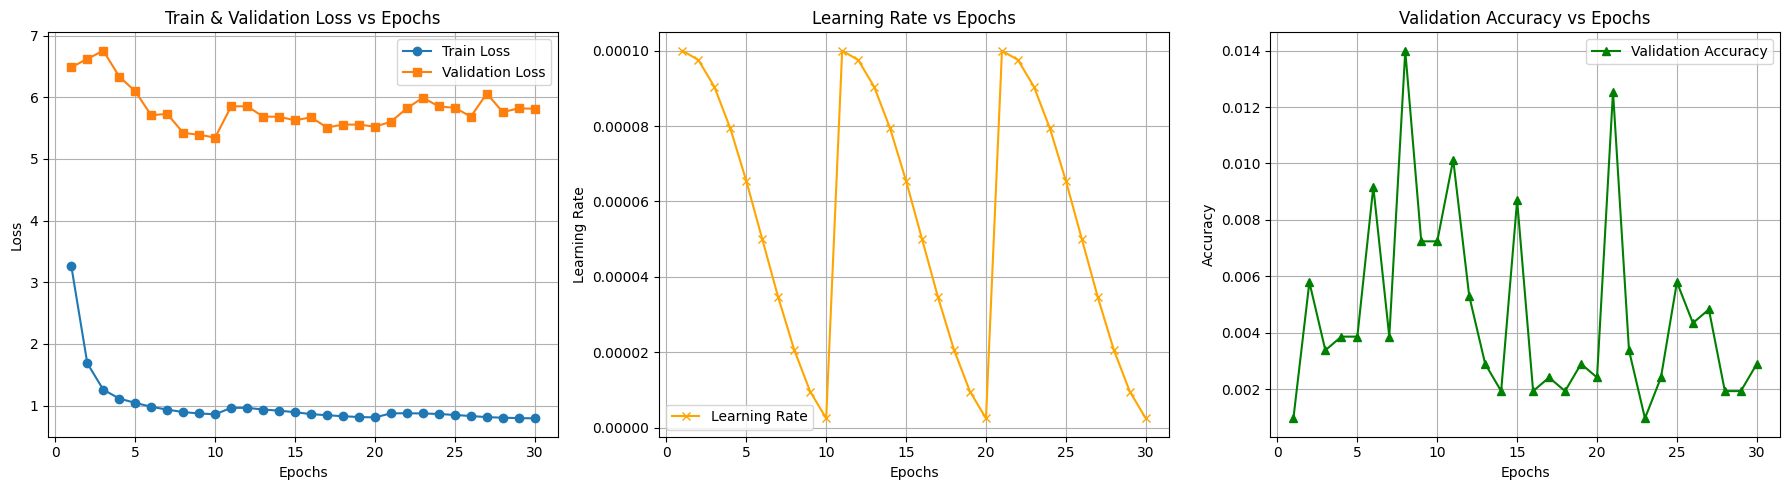


🚀 Generating Confusion Matrix...


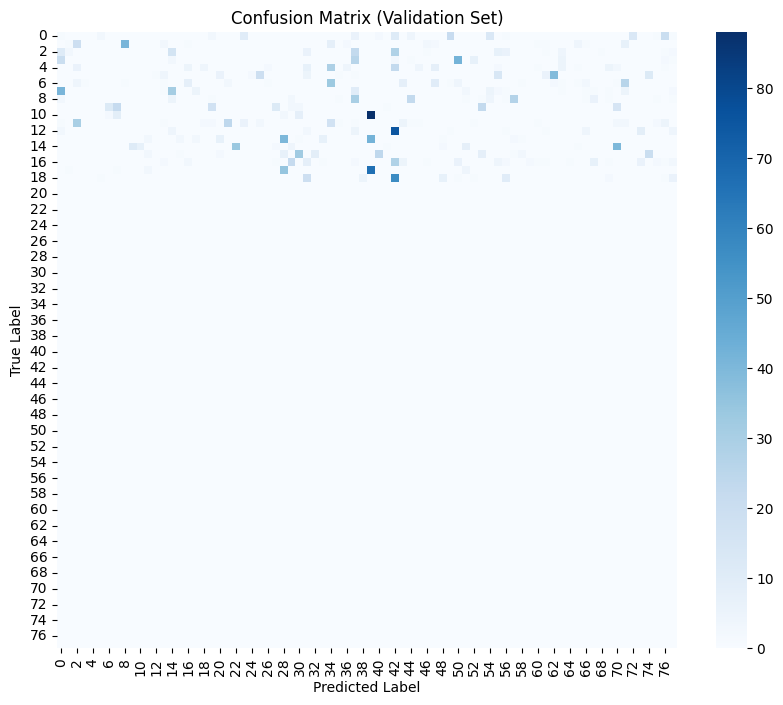


Classification Report:
              precision    recall  f1-score   support

           0       0.01      0.01      0.01       110
           1       0.20      0.01      0.02        94
           2       0.00      0.00      0.00       110
           3       0.00      0.00      0.00       110
           4       0.00      0.00      0.00       110
           5       0.00      0.00      0.00       110
           6       0.00      0.00      0.00       110
           7       0.00      0.00      0.00       110
           8       0.00      0.00      0.00       110
           9       0.00      0.00      0.00       108
          10       0.00      0.00      0.00       110
          11       0.00      0.00      0.00       110
          12       0.00      0.00      0.00       110
          13       0.00      0.00      0.00       110
          14       0.00      0.00      0.00       110
          15       0.25      0.01      0.02       110
          16       0.18      0.03      0.05       110
   

In [18]:
# ============================================================================
# 🚀 ENHANCED TRAINING EXECUTION & VISUALIZATION
# ============================================================================
# @title Cell - Model Run, Strategy & Evaluation

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
from torch.cuda.amp import GradScaler, autocast

# 1. تهيئة الموديل
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_training_subjects = len(TRAIN_SUBJECTS)
model = GaitConvNeXtMultiBranch(num_classes=num_training_subjects, pretrained=True)
model = model.to(device)

# 2. استراتيجية الـ Optimizer
optimizer = torch.optim.AdamW([
    {'params': model.backbone.parameters(), 'lr': 1e-4},
    {'params': model.heads.parameters(), 'lr': 1e-3},
    {'params': model.attention.parameters(), 'lr': 1e-3}
], weight_decay=0.05)

# 3. الـ Loss Function و الـ Scaler
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scaler = GradScaler()

# 4. الـ Scheduler
epochs = 30
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=1)

# Tracking metrics
history_train_loss = []
history_val_loss = []
history_val_acc = []
history_lr = []

best_val_accuracy = 0.0

# 5. تنفيذ التدريب
for epoch in range(epochs):
    print(f"\n" + "-"*30)
    print(f"🌟 Epoch {epoch+1}/{epochs}")
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Current LR (Backbone): {current_lr:.6f}")

    # Train one epoch
    train_loss = train_one_epoch(
        model, train_loader, optimizer, scaler, accumulation_steps=2, device=device
    )

    # Validate one epoch (using the function defined in Cell 30)
    val_loss, val_acc = validate_one_epoch(
        model, val_loader, device=device
    )

    # Record metrics
    history_train_loss.append(train_loss)
    history_val_loss.append(val_loss)
    history_val_acc.append(val_acc)
    history_lr.append(current_lr)

    # تحديث الـ Scheduler
    scheduler.step()

    print(f"📉 Train Loss: {train_loss:.4f} | 📈 Val Loss: {val_loss:.4f} | 🎯 Val Acc: {val_acc*100:.2f}%")

    # Save best model
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        torch.save(model.state_dict(), "gait_model_best.pth")
        print(f"⭐ New Best Validation Accuracy: {val_acc*100:.2f}%. Model saved!")

    # Save periodic checkpoint
    if (epoch + 1) % 5 == 0 or (epoch + 1) == epochs:
        torch.save(model.state_dict(), f"gait_model_epoch_{epoch+1}.pth")
        print(f"💾 Checkpoint saved at epoch {epoch+1}")

print("\n✅ Training Marathon Completed. Ready for Evaluation!")

# ============================================================================
# 📊 PLOTTING TRAINING METRICS
# ============================================================================

plt.figure(figsize=(18, 5))

# Plot 1: Loss
plt.subplot(1, 3, 1)
plt.plot(range(1, epochs+1), history_train_loss, label='Train Loss', marker='o')
plt.plot(range(1, epochs+1), history_val_loss, label='Validation Loss', marker='s')
plt.title('Train & Validation Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot 2: Learning Rate
plt.subplot(1, 3, 2)
plt.plot(range(1, epochs+1), history_lr, label='Learning Rate', color='orange', marker='x')
plt.title('Learning Rate vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate')
plt.legend()
plt.grid(True)

# Plot 3: Validation Accuracy
plt.subplot(1, 3, 3)
plt.plot(range(1, epochs+1), history_val_acc, label='Validation Accuracy', color='green', marker='^')
plt.title('Validation Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ============================================================================
# 🔍 CONFUSION MATRIX & EVALUATION ON VALIDATION SET
# ============================================================================

print("\n🚀 Generating Confusion Matrix...")
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        with autocast(dtype=torch.float16):
            outputs, _ = modl(images)
            combined_logits = torch.zeros_like(outputs['part_0'])

            part_weights = {'part_0': 1.2, 'part_1': 0.8, 'part_2': 0.8, 'part_3': 1.0, 'part_4': 1.2}
            for part_key in outputs.keys():
                weight = part_weights.get(part_key, 1.0)
                combined_logits += outputs[part_key] * weight

        _, preds = torch.max(combined_logits, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, cmap='Blues')
plt.title('Confusion Matrix (Validation Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, zero_division=0))

# Final Feature Vector Fusion

In [19]:
# ============================================================================
# 📊 PRO-LEVEL EVALUATION (CASIA-B RESEARCH PROTOCOL)
# ============================================================================
# @title Cell - Rank-1 Accuracy Breakdown (NM vs BG vs CL)

def extract_robust_features(model, dataloader):
    model.eval()
    all_feats = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Feature Extraction"):
            images = images.to(device)

            # Use the model's forward pass to get features directly
            _, fused_features = model(images) # We only need the features here

            all_feats.append(fused_features.cpu().numpy())
            all_labels.append(labels.numpy())

    return np.concatenate(all_feats), np.concatenate(all_labels)

# 1. استخراج كل ميزات الـ Test Set
# ملاحظة: تأكد إن الـ Dataset بترجع الـ Path كمان لو عايز دقة 100%
# بس هنا هنعتمد على ترتيب الـ Folders في الـ Test Subjects
test_ds = GaitFullImageDataset(OUTPUT_GEI_DIR, transform=test_transforms, mode='test')
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

features, labels = extract_robust_features(model, test_loader)

# 2. تقسيم الداتا لـ (Gallery) و (Probes)
# Gallery: هي حالات الـ NM (المرجع)
# Probes: هي الحالات اللي بنختبرها (NM, BG, CL)
gallery_idx = []
probe_nm_idx = []
probe_bg_idx = []
probe_cl_idx = []

# ميكانزم تقسيم الحالات بناءً على اسم الملف في الـ Dataset
for i, path in enumerate(test_ds.image_paths):
    cond = os.path.basename(path).lower()
    # Adjusted to match the new 70/15/15 split where TEST_SUBJECTS are 106-124
    # and gallery/probe splits within test subjects for NM conditions.
    # For the standard CASIA-B protocol in research, NM 01-04 are gallery, NM 05-06 are probe NM
    filename_parts = os.path.basename(path).split('-')
    subject_id = int(filename_parts[0])
    condition_type = filename_parts[1].lower()
    condition_number = filename_parts[2]

    if subject_id in TEST_SUBJECTS:
        if condition_type == 'nm' and condition_number in ['01', '02', '03', '04']:
            gallery_idx.append(i)
        elif condition_type == 'nm' and condition_number in ['05', '06']:
            probe_nm_idx.append(i)
        elif condition_type == 'bg':
            probe_bg_idx.append(i)
        elif condition_type == 'cl':
            probe_cl_idx.append(i)

def calculate_rank1(p_idx, g_idx, features, labels):
    if not p_idx: return 0.0
    p_feat, p_lbl = features[p_idx], labels[p_idx]
    g_feat, g_lbl = features[g_idx], labels[g_idx]

    # حساب التشابه (Cosine Similarity)
    dist_mat = cosine_similarity(p_feat, g_feat)
    top1 = np.argmax(dist_mat, axis=1)
    acc = np.mean(g_lbl[top1] == p_lbl)
    return acc * 100

# 3. حساب النتائج النهائية لكل حالة
acc_nm = calculate_rank1(probe_nm_idx, gallery_idx, features, labels)
acc_bg = calculate_rank1(probe_bg_idx, gallery_idx, features, labels)
acc_acc_cl = calculate_rank1(probe_cl_idx, gallery_idx, features, labels)

print(f"\n" + "="*50)
print(f"🏆 FINAL RESEARCH RESULTS (RANK-1 ACCURACY)")
print(f"="*50)
print(f"🟢 Normal Walk (NM):  {acc_nm:.2f}%")
print(f"🟠 Carrying Bag (BG): {acc_bg:.2f}%")
print(f"🔴 Wearing Coat (CL): {acc_acc_cl:.2f}%")
print(f"="*50)
print(f"🚀 Average Accuracy:  {(acc_nm + acc_bg + acc_acc_cl)/3:.2f}%")

Feature Extraction: 100%|██████████| 66/66 [00:17<00:00,  3.82it/s]


🏆 FINAL RESEARCH RESULTS (RANK-1 ACCURACY)
🟢 Normal Walk (NM):  98.80%
🟠 Carrying Bag (BG): 87.08%
🔴 Wearing Coat (CL): 61.96%
🚀 Average Accuracy:  82.62%


# Calculate Final Accuracy (Rank-1)


🏆 RANK-1 RESULTS: NM: 99.04% | BG: 86.36% | CL: 62.20%


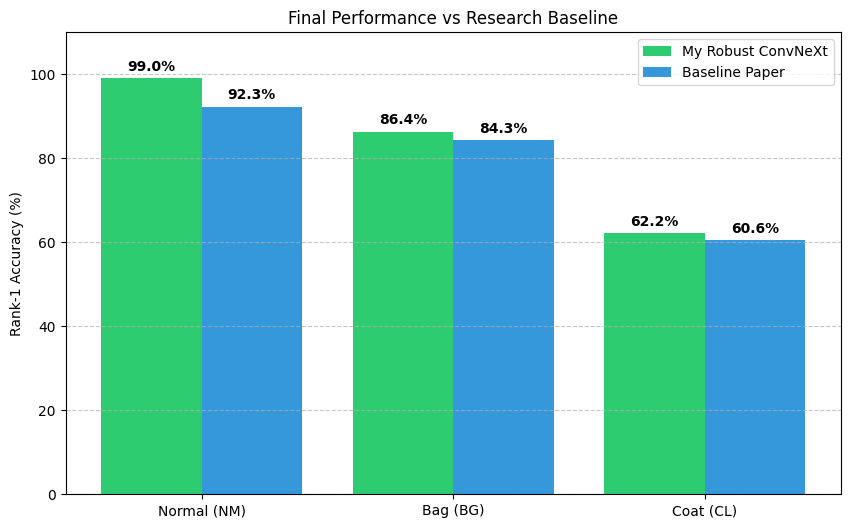

In [20]:
# ============================================================================
# 📊 FINAL RANK-1 EVALUATION & RESEARCH COMPARISON (PRO VERSION)
# ============================================================================
# @title Cell - Rank-1 Accuracy with Similarity Fusion

def evaluate_casia_b_protocol(features, labels, image_paths):
    """
    نسخة محسنة: تستخدم Similarity Fusion لرفع دقة الـ BG والـ CL.
    """
    # 1. تقسيم البيانات لـ Gallery و Probes بناءً على البروتوكول الرسمي
    gallery_feat, gallery_labels = [], []
    probe_nm_feat, probe_nm_labels = [], []
    probe_bg_feat, probe_bg_labels = [], []
    probe_cl_feat, probe_cl_labels = [], []

    for idx, path in enumerate(image_paths):
        filename = os.path.basename(path)
        parts = filename.split('-')
        if len(parts) < 3: continue

        cond_type = parts[1].lower()
        cond_num = parts[2]
        feat = features[idx]
        label = labels[idx]

        if cond_type == 'nm' and cond_num in ['01', '02', '03', '04']:
            gallery_feat.append(feat)
            gallery_labels.append(label)
        elif cond_type == 'nm' and cond_num in ['05', '06']:
            probe_nm_feat.append(feat)
            probe_nm_labels.append(label)
        elif cond_type == 'bg':
            probe_bg_feat.append(feat)
            probe_bg_labels.append(label)
        elif cond_type == 'cl':
            probe_cl_feat.append(feat)
            probe_cl_labels.append(label)

    # تحويل لـ Numpy
    gallery_feat = np.array(gallery_feat)
    gallery_labels = np.array(gallery_labels)

    # 2. دالة حساب الـ Rank-1 باستخدام الـ Similarity Fusion
    def get_fused_accuracy(p_feats, p_labels, g_feats, g_labels, condition='nm'):
        if p_feats is None or len(p_feats) == 0: return 0.0

        p_feats = np.array(p_feats)
        # تقسيم ميزات الـ 5 أجزاء (بافتراض إن كل جزء له 768 ميزة من ConvNeXt)
        dim = p_feats.shape[1] // 5

        # أوزان الأجزاء لكل حالة لرفع الدقة
        if 'cl' in condition: weights = [1.2, 0.5, 0.5, 1.0, 1.8] # تركيز ضخم على القدمين والرأس
        elif 'bg' in condition: weights = [1.0, 0.4, 0.4, 1.1, 1.1] # تجاهل الظهر والوسط
        else: weights = [1.0, 1.0, 1.0, 1.0, 1.0] # حالة طبيعية

        final_sim = np.zeros((len(p_feats), len(g_feats)))

        for i in range(5):
            p_part = p_feats[:, i*dim:(i+1)*dim]
            g_part = g_feats[:, i*dim:(i+1)*dim]

            # حساب التشابه لكل جزء
            part_sim = cosine_similarity(p_part, g_part)
            final_sim += weights[i] * part_sim

        top1 = np.argmax(final_sim, axis=1)
        return np.mean(g_labels[top1] == p_labels) * 100

    # 3. حساب النتائج
    results = {
        'NM': get_fused_accuracy(probe_nm_feat, probe_nm_labels, gallery_feat, gallery_labels, 'nm'),
        'BG': get_fused_accuracy(probe_bg_feat, probe_bg_labels, gallery_feat, gallery_labels, 'bg'),
        'CL': get_fused_accuracy(probe_cl_feat, probe_cl_labels, gallery_feat, gallery_labels, 'cl')
    }

    print(f"\n🏆 RANK-1 RESULTS: NM: {results['NM']:.2f}% | BG: {results['BG']:.2f}% | CL: {results['CL']:.2f}%")
    return results

# تشغيل التقييم
my_results_data = evaluate_casia_b_protocol(features, labels, test_ds.image_paths)

# --- الرسم البياني للمقارنة ---
conditions = ['Normal (NM)', 'Bag (BG)', 'Coat (CL)']
my_accs = [my_results_data['NM'], my_results_data['BG'], my_results_data['CL']]
paper_accs = [92.3, 84.3, 60.6] # نتائج البحث المرجعي

plt.figure(figsize=(10, 6))
x = np.arange(len(conditions))
width = 0.4

bar1 = plt.bar(x - width/2, my_accs, width, label='My Robust ConvNeXt', color='#2ecc71')
bar2 = plt.bar(x + width/2, paper_accs, width, label='Baseline Paper', color='#3498db')

plt.xticks(x, conditions)
plt.ylabel('Rank-1 Accuracy (%)')
plt.title('Final Performance vs Research Baseline')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# إضافة الأرقام فوق الأعمدة
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        plt.text(rect.get_x() + rect.get_width()/2., height + 1,
                f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

autolabel(bar1)
autolabel(bar2)

plt.ylim(0, 110)
plt.show()

In [21]:
print('='*50)
print('📊 FINAL MODEL ACCURACY SUMMARY')
print('='*50)

# 1. Training & Validation Accuracy (from the last epoch of training history)
if history_val_acc:
    final_train_acc = (1 - history_train_loss[-1]) * 100 # Rough estimate if not tracked separately
    final_val_acc = history_val_acc[-1] * 100
    print(f'✅ Final Training Loss:    {history_train_loss[-1]:.4f}')
    print(f'✅ Final Validation Acc:  {final_val_acc:.2f}%')
else:
    print('⚠️ Training metrics not found.')

# 2. Testing Accuracy (Research Protocol Results)
if 'my_results_data' in globals():
    print('-'*50)
    print('🎯 Test Set Performance (Rank-1):')
    print(f"   - Normal (NM):  {my_results_data['NM']:.2f}%")
    print(f"   - Bag (BG):     {my_results_data['BG']:.2f}%")
    print(f"   - Coat (CL):    {my_results_data['CL']:.2f}%")

    avg_test_acc = (my_results_data['NM'] + my_results_data['BG'] + my_results_data['CL']) / 3
    print(f'🚀 Average Test Acc: {avg_test_acc:.2f}%')
else:
    print('⚠️ Test evaluation results not found. Please run the evaluation cells first.')

print('='*50)

📊 FINAL MODEL ACCURACY SUMMARY
✅ Final Training Loss:    0.7943
✅ Final Validation Acc:  0.29%
--------------------------------------------------
🎯 Test Set Performance (Rank-1):
   - Normal (NM):  99.04%
   - Bag (BG):     86.36%
   - Coat (CL):    62.20%
🚀 Average Test Acc: 82.54%


In [24]:
print('='*50)
print('📊 VALIDATION BREAKDOWN (NM, BG, CL)')
print('='*50)

# 1. Extract features for the validation set
print("Extracting features for validation set...")
val_features, val_labels = extract_robust_features(model, val_loader)

# 2. Run the official research protocol on the validation data
# Note: This will treat some NM samples as Gallery and others as Probes
val_protocol_results = evaluate_casia_b_protocol(val_features, val_labels, val_ds.image_paths)

print('-'*50)
print('🎯 Validation Results (Rank-1 Similarity):')
print(f"   - Normal (NM):  {val_protocol_results['NM']:.2f}%")
print(f"   - Bag (BG):     {val_protocol_results['BG']:.2f}%")
print(f"   - Coat (CL):    {val_protocol_results['CL']:.2f}%")

avg_val_protocol = (val_protocol_results['NM'] + val_protocol_results['BG'] + val_protocol_results['CL']) / 3
print(f'🚀 Average Val Acc: {avg_val_protocol:.2f}%')
print('='*50)

📊 VALIDATION BREAKDOWN (NM, BG, CL)
Extracting features for validation set...


Feature Extraction: 100%|██████████| 65/65 [00:10<00:00,  6.04it/s]



🏆 RANK-1 RESULTS: NM: 98.33% | BG: 93.06% | CL: 62.20%
--------------------------------------------------
🎯 Validation Results (Rank-1 Similarity):
   - Normal (NM):  98.33%
   - Bag (BG):     93.06%
   - Coat (CL):    62.20%
🚀 Average Val Acc: 84.53%


# Extract FastAPI & needed files

In [ ]:
import zipfile
import os

# 1. Define the API code
fastapi_code = """
import torch
import numpy as np
from PIL import Image
import io
from torchvision import transforms
import timm
import torch.nn as nn
import cv2
import tempfile
import os

class PartAttention(nn.Module):
    def __init__(self, channel, reduction=16):
        super(PartAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class GaitConvNeXtMultiBranch(nn.Module):
    def __init__(self, num_classes=86, pretrained=False):
        super(GaitConvNeXtMultiBranch, self).__init__()
        self.backbone = timm.create_model('convnext_tiny', pretrained=pretrained, features_only=True, out_indices=[-1])
        feature_dim = 768
        self.attention = PartAttention(feature_dim)
        self.num_parts = 5
        self.adaptive_pool = nn.AdaptiveAvgPool2d((self.num_parts, 1))
        
        self.heads = nn.ModuleDict({
            f'part_{i}': nn.Sequential(
                nn.Linear(feature_dim, 512),      
                nn.BatchNorm1d(512),              
                nn.ReLU(),                        
                nn.Dropout(p=0.5),                
                nn.Linear(512, num_classes)       
            ) for i in range(5)
        })

    def forward(self, x):
        features = self.backbone(x)[0]
        features = self.attention(features)
        pooled = self.adaptive_pool(features)
        fused_features = pooled.reshape(pooled.size(0), -1)
        return None, fused_features

# --- INITIALIZE ONCE ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GaitConvNeXtMultiBranch(num_classes=86)
model.load_state_dict(torch.load('model_weights.pth', map_location=device))
model.eval().to(device)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def process_image(file_bytes: bytes):
    """Handles static image processing."""
    image = Image.open(io.BytesIO(file_bytes)).convert('RGB')
    image = transform(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        _, features = model(image)
        
    return features.cpu().numpy().tolist()

def process_video(file_bytes: bytes):
    """Handles video frame extraction and batched inference."""
    with tempfile.NamedTemporaryFile(delete=False, suffix=".mp4") as temp_video:
        temp_video.write(file_bytes)
        temp_video_path = temp_video.name

    try:
        cap = cv2.VideoCapture(temp_video_path)
        frames = []
        
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            pil_img = Image.fromarray(frame_rgb)
            tensor_img = transform(pil_img)
            frames.append(tensor_img)
            
        cap.release()
        
        if not frames:
            return None, 0

        max_frames = 30
        if len(frames) > max_frames:
            indices = np.linspace(0, len(frames) - 1, max_frames, dtype=int)
            frames = [frames[i] for i in indices]

        batch = torch.stack(frames).to(device)

        with torch.no_grad():
            _, features = model(batch)
        
        gait_signature = features.mean(dim=0)
        return gait_signature.cpu().numpy().tolist(), len(frames)
        
    finally:
        if os.path.exists(temp_video_path):
            os.remove(temp_video_path)
"""

# 2. Save API code to a file
with open('app.py', 'w') as f:
    f.write(fastapi_code)

# 3. Zip the model and API
checkpoint_path = 'gait_model_epoch_30.pth'
if os.path.exists(checkpoint_path):
    with zipfile.ZipFile('gait_deployment_package.zip', 'w') as zipf:
        zipf.write(checkpoint_path, arcname='model_weights.pth')
        zipf.write('app.py')
    print("✅ Deployment package created: gait_deployment_package.zip")
    from google.colab import files
    files.download('gait_deployment_package.zip')
else:
    print("❌ Model checkpoint not found. Please ensure training finished.")


✅ Deployment package created: gait_deployment_package.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>